# Notebook 2 — High-Accuracy Kaggle Version: PP-HFL Real-Time Federated Learning

This notebook is tuned for stronger results while still keeping your dissertation components:

1. **Real-time FL** — ECG data arrives in large streaming windows.
2. **Heterogeneous FL** — clients have different local epochs, learning rates, data distributions and simulated latency.
3. **Privacy-preserving FL** — update clipping + very light Gaussian noise are applied before aggregation.

Important:
- This version is **accuracy-first**.
- DP noise is intentionally very small because strong DP noise can reduce model performance.
- After the FL rounds, an optional **personalization/fine-tuning step** is included to improve the final model further.

In [1]:
# ============================================================
# Kaggle-ready setup
# Project: Cardiovascular Disease Prediction using a
# Privacy-Preserving Heterogeneous Real-Time Federated Learning Framework
# ============================================================

import os, time, zipfile, random, warnings, math, json
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, classification_report, confusion_matrix,
    roc_curve, auc, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D, Dropout,
    LayerNormalization, Bidirectional, LSTM, GlobalMaxPooling1D,
    Dense
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-29 14:10:21.848090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782742222.047205      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782742222.103378      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782742222.553008      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782742222.553061      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782742222.553064      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
# Data loading utilities
# Supports:
# 1. Kaggle datasets mounted under /kaggle/input
# 2. Zenodo download fallback, if Kaggle internet is enabled
# 3. Synthetic ECG fallback, for debugging only
# ============================================================

CLIENT_ZENODO_TEMPLATE = "https://zenodo.org/records/16739305/files/ecg_aug_model{client_id}.zip?download=1"
TEST_ZENODO_URL = "https://zenodo.org/records/16730029/files/test_models.zip?download=1"

DATA_DIR = Path("/kaggle/working/dataset")
TEST_DIR = Path("/kaggle/working/test_models")
DATA_DIR.mkdir(parents=True, exist_ok=True)

def unzip_file(zip_path, extract_dir):
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    return extract_dir

def find_npz_dir(root, contains=None):
    root = Path(root)
    candidates = []
    for p in root.rglob("*"):
        if p.is_dir() and list(p.glob("*.npz")):
            candidates.append(p)
    if contains:
        contains = str(contains)
        for p in candidates:
            if contains in str(p):
                return p
    return candidates[0] if candidates else None

def download_file(url, output_path):
    import requests
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading: {url}")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    print("Saved:", output_path)
    return output_path

def process_npz_files(directory):
    directory = Path(directory)
    files = sorted(directory.glob("*.npz"))
    if len(files) == 0:
        raise FileNotFoundError(f"No .npz files found in {directory}")
    X, y = [], []
    for fp in tqdm(files, desc=f"Loading {directory.name}"):
        with np.load(fp) as data:
            X.append(data["x"])
            y.append(int(np.array(data["y"]).item()))
    X = np.asarray(X).astype("float32")
    labels = np.asarray(y)
    classes, indexed = np.unique(labels, return_inverse=True)
    y_1hot = np.eye(len(classes), dtype="float32")[indexed]
    return X, y_1hot, classes

def make_synthetic_ecg(n_samples=1200, n_classes=6, timesteps=600, channels=8):
    print("WARNING: Using synthetic ECG-like data only because real data was not found.")
    X = np.random.normal(0, 0.5, size=(n_samples, timesteps, channels)).astype("float32")
    labels = np.random.randint(0, n_classes, size=n_samples)
    t = np.linspace(0, 1, timesteps)
    for i in range(n_samples):
        cls = labels[i]
        freq = 3 + cls
        signal = np.sin(2 * np.pi * freq * t) + 0.3*np.sin(2*np.pi*(freq*2)*t)
        X[i, :, 0] += signal.astype("float32")
        X[i, :, cls % channels] += 0.5 * signal.astype("float32")
    y = np.eye(n_classes, dtype="float32")[labels]
    return X, y, np.arange(n_classes)

def load_client_data(client_id=1, allow_download=True, synthetic_if_missing=True):
    # 1) Try Kaggle input first.
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidate = find_npz_dir(kaggle_root, contains=f"model{client_id}")
        if candidate is not None:
            print("Found Kaggle input:", candidate)
            return process_npz_files(candidate)

    # 2) Try already extracted working directory.
    candidate = find_npz_dir(DATA_DIR, contains=f"model{client_id}")
    if candidate is not None:
        print("Found working dataset:", candidate)
        return process_npz_files(candidate)

    # 3) Download from Zenodo if allowed.
    if allow_download:
        try:
            zip_path = Path(f"/kaggle/working/ecg_aug_model{client_id}.zip")
            url = CLIENT_ZENODO_TEMPLATE.format(client_id=client_id)
            download_file(url, zip_path)
            unzip_file(zip_path, DATA_DIR)
            candidate = find_npz_dir(DATA_DIR, contains=f"model{client_id}")
            if candidate is not None:
                return process_npz_files(candidate)
        except Exception as e:
            print("Download failed:", repr(e))

    # 4) Synthetic fallback.
    if synthetic_if_missing:
        return make_synthetic_ecg()
    raise FileNotFoundError("Could not load ECG client data.")

def load_test_data(allow_download=True, synthetic_if_missing=True):
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidate = find_npz_dir(kaggle_root, contains="test")
        if candidate is not None:
            print("Found Kaggle test input:", candidate)
            return process_npz_files(candidate)

    candidate = find_npz_dir(TEST_DIR, contains="test")
    if candidate is not None:
        return process_npz_files(candidate)

    if allow_download:
        try:
            zip_path = Path("/kaggle/working/test_models.zip")
            download_file(TEST_ZENODO_URL, zip_path)
            unzip_file(zip_path, TEST_DIR)
            candidate = find_npz_dir(TEST_DIR, contains="test")
            if candidate is not None:
                return process_npz_files(candidate)
        except Exception as e:
            print("Test download failed:", repr(e))

    if synthetic_if_missing:
        return make_synthetic_ecg(n_samples=300)
    raise FileNotFoundError("Could not load test data.")

In [4]:
# ============================================================
# Model and evaluation utilities
# ============================================================

def build_cnn_bilstm(input_shape=(600, 8), n_classes=6, variant="medium"):
    reg = tf.keras.regularizers.l2(1e-4)

    if variant == "small":
        filters, lstm1, lstm2, dense = 64, 64, 32, 64
        dropout = 0.25
    elif variant == "large":
        filters, lstm1, lstm2, dense = 160, 160, 96, 160
        dropout = 0.40
    else:
        filters, lstm1, lstm2, dense = 128, 128, 64, 128
        dropout = 0.35

    return Sequential([
        Input(shape=input_shape),

        Conv1D(filters, 7, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),

        Conv1D(filters, 5, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(3),
        Dropout(dropout),

        Conv1D(filters, 5, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(3),
        Dropout(dropout),

        LayerNormalization(),

        Bidirectional(LSTM(lstm1, return_sequences=True, kernel_regularizer=reg)),
        Dropout(dropout),

        Bidirectional(LSTM(lstm2, return_sequences=True, kernel_regularizer=reg)),
        GlobalMaxPooling1D(),
        Dropout(dropout),

        Dense(dense, activation="relu", kernel_regularizer=reg, kernel_initializer="orthogonal"),
        Dropout(dropout),
        Dense(n_classes, activation="softmax")
    ])

def compile_model(model, lr=1e-3, label_smoothing=0.0):
    # Use a normal float learning rate so ReduceLROnPlateau can update it.
    # Do NOT use ExponentialDecay together with ReduceLROnPlateau.
    optimizer = tf.keras.optimizers.Adam(learning_rate=float(lr))
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ],
    )
    return model

def evaluate_model(model, X, y, title="Evaluation", plot_roc=True):
    prob = model.predict(X, verbose=0)
    pred = np.argmax(prob, axis=1)
    true = np.argmax(y, axis=1)

    results = {
        "accuracy": accuracy_score(true, pred),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "precision_macro": precision_score(true, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(true, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(true, pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(true, pred),
    }

    print("\\n" + "="*70)
    print(title)
    print("="*70)
    for k, v in results.items():
        print(f"{k:20s}: {v:.4f}")
    print("\\nClassification report:")
    print(classification_report(true, pred, zero_division=0))

    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(7, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    if plot_roc:
        n_classes = y.shape[1]
        true_bin = label_binarize(true, classes=np.arange(n_classes))
        plt.figure(figsize=(7, 5))
        for i in range(n_classes):
            try:
                fpr, tpr, _ = roc_curve(true_bin[:, i], prob[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")
            except Exception:
                pass
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {title}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return results

def plot_history(history, title="Training"):
    hist = pd.DataFrame(history.history)
    for cols, ylabel in [(["accuracy", "val_accuracy"], "Accuracy"), (["loss", "val_loss"], "Loss")]:
        plt.figure(figsize=(7, 4))
        for c in cols:
            if c in hist:
                plt.plot(hist[c], label=c)
        plt.title(f"{title} - {ylabel}")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [6]:
# ============================================================
# Federated Learning utilities:
# - Real-time streaming by chunking incoming ECG data
# - Heterogeneity through non-IID data, client sizes, epochs, LR, latency
# - Privacy-preserving FL through clipping + Gaussian noise
# - Simulated secure aggregation using random masks
# ============================================================

def clone_compiled_model(global_model, lr=1e-3):
    m = tf.keras.models.clone_model(global_model)
    m.set_weights(global_model.get_weights())
    compile_model(m, lr=lr)
    return m

def l2_norm_weights(weights):
    return float(np.sqrt(sum(np.sum(np.square(w)) for w in weights)))

def clip_weights_update(update, clip_norm=1.0):
    norm = l2_norm_weights(update)
    scale = min(1.0, clip_norm / (norm + 1e-12))
    return [u * scale for u in update], norm, scale

def add_gaussian_noise(update, noise_multiplier=0.05, clip_norm=1.0):
    if noise_multiplier <= 0:
        return update
    std = noise_multiplier * clip_norm
    return [u + np.random.normal(0, std, size=u.shape).astype(u.dtype) for u in update]

def get_update(new_weights, old_weights):
    return [nw - ow for nw, ow in zip(new_weights, old_weights)]

def apply_update(weights, update):
    return [w + u for w, u in zip(weights, update)]

def weighted_average_updates(updates, weights):
    total = np.sum(weights)
    agg = []
    for layer_i in range(len(updates[0])):
        layer_sum = sum(updates[c][layer_i] * (weights[c] / total) for c in range(len(updates)))
        agg.append(layer_sum)
    return agg

def create_non_iid_clients(X, y, n_clients=4, alpha=0.4, min_size=30):
    labels = np.argmax(y, axis=1)
    n_classes = y.shape[1]
    client_indices = [[] for _ in range(n_clients)]

    for cls in range(n_classes):
        cls_idx = np.where(labels == cls)[0]
        np.random.shuffle(cls_idx)
        proportions = np.random.dirichlet(alpha * np.ones(n_clients))
        proportions = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
        splits = np.split(cls_idx, proportions)
        for c, idx in enumerate(splits):
            client_indices[c].extend(idx.tolist())

    # Fallback if a client is too small
    all_idx = np.arange(len(X))
    for c in range(n_clients):
        if len(client_indices[c]) < min_size:
            extra = np.random.choice(all_idx, size=min_size, replace=False)
            client_indices[c].extend(extra.tolist())

    clients = []
    for c in range(n_clients):
        idx = np.array(client_indices[c])
        np.random.shuffle(idx)
        clients.append((X[idx], y[idx]))
    return clients

def make_realtime_stream(X, y, chunk_size=128):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    for start in range(0, len(idx), chunk_size):
        batch_idx = idx[start:start+chunk_size]
        yield X[batch_idx], y[batch_idx]

def estimate_epsilon(rounds, noise_multiplier, delta=1e-5):
    # Lightweight approximate privacy accounting for reporting only.
    # For formal DP accounting, use TensorFlow Privacy's RDP accountant.
    if noise_multiplier <= 0:
        return np.inf
    return float((rounds * 2 * math.log(1 / delta)) ** 0.5 / noise_multiplier)

def client_data_quality_score(history, y_train):
    losses = np.array(history.history.get("loss", [1.0]), dtype=float)
    if len(losses) < 2 or losses[0] == 0:
        loss_improvement = 0.0
    else:
        loss_improvement = (losses[0] - losses[-1]) / abs(losses[0])
    stability = 1.0 / (np.std(losses) + 1e-6)

    labels = np.argmax(y_train, axis=1)
    counts = np.bincount(labels, minlength=y_train.shape[1])
    probs = counts / max(counts.sum(), 1)
    ent = -np.sum([p * np.log2(p) for p in probs if p > 0])
    ent_norm = ent / np.log2(y_train.shape[1])

    return float(max(loss_improvement, 0) * stability * ent_norm)

def secure_aggregate_simulated(updates, sample_counts):
    # Simulation of secure aggregation idea:
    # pairwise masks cancel out before server sees final aggregate.
    # This is not production cryptography; it is a dissertation simulation.
    masked = [[u.copy() for u in upd] for upd in updates]
    n = len(updates)

    for i in range(n):
        for j in range(i+1, n):
            for k in range(len(updates[0])):
                mask = np.random.normal(0, 1e-6, size=updates[0][k].shape).astype(updates[0][k].dtype)
                masked[i][k] += mask
                masked[j][k] -= mask

    return weighted_average_updates(masked, sample_counts)

def compute_balanced_class_weight(y_onehot):
    # Returns class_weight dictionary for Keras.
    # Helps improve minority-class learning, which is important in ECG classification.
    labels = np.argmax(y_onehot, axis=1)
    classes = np.arange(y_onehot.shape[1])
    counts = np.bincount(labels, minlength=len(classes)).astype(float)
    total = counts.sum()
    weights = {}
    for c in classes:
        if counts[c] > 0:
            weights[int(c)] = total / (len(classes) * counts[c])
        else:
            weights[int(c)] = 1.0
    # Avoid extremely large weights that can destabilize FL
    weights = {k: min(v, 5.0) for k, v in weights.items()}
    return weights


## Configuration

In [8]:
# ============================================================
# High-accuracy configuration
# ============================================================

NUM_CLIENTS = 4

# More rounds + larger streaming chunks help the model see enough ECG data.
FED_ROUNDS = 25
STREAM_CHUNK_SIZE = 4096
LOCAL_BATCH_SIZE = 32

# Accuracy-first privacy settings:
# Keep clipping high and noise tiny. Stronger DP noise can be tested later
# in the ablation notebook after the model is performing well.
CLIP_NORM = 100.0
NOISE_MULTIPLIER = 0.0001
DELTA = 1e-5

# Optional final personalization/fine-tuning step.
# This often improves final accuracy because each client adapts the global model.
ENABLE_FINAL_PERSONALIZATION = True
PERSONALIZATION_EPOCHS = 8

# Heterogeneous client settings:
# Different epochs, learning rates and latency preserve heterogeneity.
CLIENT_CONFIGS = [
    {"name": "Hospital-A", "epochs": 6, "lr": 1.0e-3, "latency": 0.0, "model_variant": "medium"},
    {"name": "Hospital-B", "epochs": 5, "lr": 8.0e-4, "latency": 0.1, "model_variant": "medium"},
    {"name": "Hospital-C", "epochs": 6, "lr": 6.0e-4, "latency": 0.1, "model_variant": "medium"},
    {"name": "Hospital-D", "epochs": 5, "lr": 1.2e-3, "latency": 0.0, "model_variant": "medium"},
]

## Load Data and Create Heterogeneous Clients

In [9]:
X, y, classes = load_client_data(client_id=1, allow_download=True, synthetic_if_missing=True)
print("Loaded:", X.shape, y.shape)

# Normalize ECG signals channel-wise. This is very important for CNN/LSTM convergence.
mean = X.mean(axis=(0, 1), keepdims=True)
std = X.std(axis=(0, 1), keepdims=True) + 1e-6
X = ((X - mean) / std).astype("float32")

X_train_full, X_global_test, y_train_full, y_global_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=np.argmax(y, axis=1)
)

# Keep heterogeneity, but avoid extreme class starvation.
# alpha=5.0 means clients are non-IID but still trainable.
client_datasets = create_non_iid_clients(
    X_train_full,
    y_train_full,
    n_clients=NUM_CLIENTS,
    alpha=5.0,
    min_size=3000
)

for i, (cx, cy) in enumerate(client_datasets):
    dist = np.bincount(np.argmax(cy, axis=1), minlength=y.shape[1])
    print(f"Client {i+1} {CLIENT_CONFIGS[i]['name']} | samples={len(cx)} | class distribution={dist.tolist()}")

Downloading: https://zenodo.org/records/16739305/files/ecg_aug_model1.zip?download=1
Saved: /kaggle/working/ecg_aug_model1.zip


Loading model1:   0%|          | 0/33073 [00:00<?, ?it/s]

Loaded: (33073, 600, 8) (33073, 6)
Client 1 Hospital-A | samples=6925 | class distribution=[1511, 726, 1324, 778, 1512, 1074]
Client 2 Hospital-B | samples=6853 | class distribution=[642, 1254, 1212, 1235, 947, 1563]
Client 3 Hospital-C | samples=7499 | class distribution=[666, 1122, 1450, 1174, 1666, 1421]
Client 4 Hospital-D | samples=5181 | class distribution=[1711, 1458, 556, 423, 486, 547]


## Initialize Global Model

In [10]:
global_model = build_cnn_bilstm(input_shape=X.shape[1:], n_classes=y.shape[1], variant="medium")
compile_model(global_model, lr=1e-3, label_smoothing=0.0)
global_model.summary()

I0000 00:00:1782742934.388108      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 600, 128)       │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 600, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 600, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 600, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 66, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 66, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 66, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 66, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 66, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 66, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,990 (2.36 MB)

 Trainable params: 617,222 (2.35 MB)

 Non-trainable params: 768 (3.00 KB)

## Federated Training Loop


FEDERATED ROUND 1/25

Client 1 (Hospital-A) streaming train samples: 3481


I0000 00:00:1782742950.371950     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


Update norm=79.2830, clip_scale=1.0000, DQA=1.4820, best_val_acc=0.4439

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=48.5756, clip_scale=1.0000, DQA=1.4334, best_val_acc=0.4130

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=37.1407, clip_scale=1.0000, DQA=1.5027, best_val_acc=0.4309

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=93.6446, clip_scale=1.0000, DQA=1.3211, best_val_acc=0.3480
\n======================================================================
Global Model after Round 1
accuracy            : 0.3748
balanced_accuracy   : 0.3796
precision_macro     : 0.3563
recall_macro        : 0.3796
f1_macro            : 0.3284
mcc                 : 0.2630
\nClassification report:
              precision    recall  f1-score   support

           0       0.24      0.02      0.04      1133
           1       0.45      0.31      0.37      1140
           2       0.36      0.15      0.21      1135
           3       0.30      0.56    

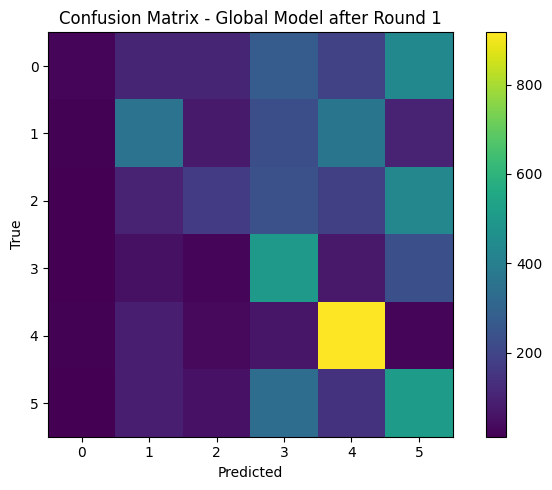


FEDERATED ROUND 2/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=24.6894, clip_scale=1.0000, DQA=1.7726, best_val_acc=0.4706

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=27.8039, clip_scale=1.0000, DQA=1.6130, best_val_acc=0.4010

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=28.0928, clip_scale=1.0000, DQA=1.7497, best_val_acc=0.4795

Client 4 (Hospital-D) streaming train samples: 922
Update norm=20.5304, clip_scale=1.0000, DQA=1.4758, best_val_acc=0.3190
\n======================================================================
Global Model after Round 2
accuracy            : 0.4272
balanced_accuracy   : 0.4309
precision_macro     : 0.4123
recall_macro        : 0.4309
f1_macro            : 0.4025
mcc                 : 0.3200
\nClassification report:
              precision    recall  f1-score   support

           0       0.33      0.21      0.26      1133
           1       0.47      0.37      0.41      1140
           2     

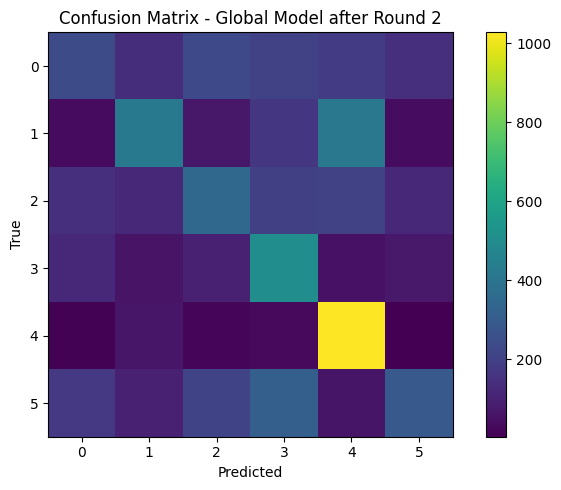


FEDERATED ROUND 3/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=64.8273, clip_scale=1.0000, DQA=1.7798, best_val_acc=0.4780

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=44.7090, clip_scale=1.0000, DQA=1.7387, best_val_acc=0.5057

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=26.9721, clip_scale=1.0000, DQA=1.9578, best_val_acc=0.5642

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=76.7217, clip_scale=1.0000, DQA=1.6511, best_val_acc=0.3886
\n======================================================================
Global Model after Round 3
accuracy            : 0.5036
balanced_accuracy   : 0.5051
precision_macro     : 0.5019
recall_macro        : 0.5051
f1_macro            : 0.4807
mcc                 : 0.4109
\nClassification report:
              precision    recall  f1-score   support

           0       0.51      0.17      0.25      1133
           1       0.54      0.58      0.56      1140
           2    

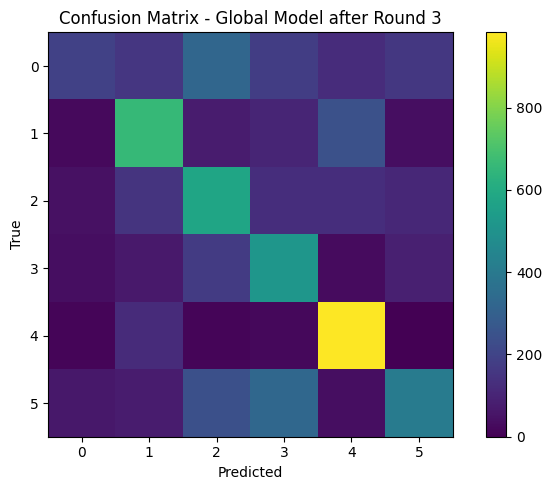


FEDERATED ROUND 4/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=28.7258, clip_scale=1.0000, DQA=1.8809, best_val_acc=0.5294

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=20.3924, clip_scale=1.0000, DQA=1.8938, best_val_acc=0.5531

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=24.0267, clip_scale=1.0000, DQA=2.1298, best_val_acc=0.6027

Client 4 (Hospital-D) streaming train samples: 922
Update norm=19.3164, clip_scale=1.0000, DQA=1.8439, best_val_acc=0.4601
\n======================================================================
Global Model after Round 4
accuracy            : 0.5723
balanced_accuracy   : 0.5742
precision_macro     : 0.5667
recall_macro        : 0.5742
f1_macro            : 0.5645
mcc                 : 0.4891
\nClassification report:
              precision    recall  f1-score   support

           0       0.46      0.41      0.44      1133
           1       0.64      0.56      0.60      1140
           2     

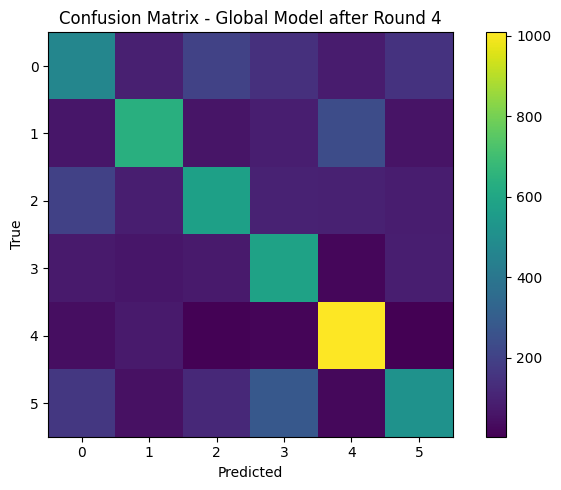


FEDERATED ROUND 5/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=39.1679, clip_scale=1.0000, DQA=2.3637, best_val_acc=0.6520

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=20.4776, clip_scale=1.0000, DQA=2.1781, best_val_acc=0.6114

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=21.8326, clip_scale=1.0000, DQA=2.1842, best_val_acc=0.6276

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=50.1005, clip_scale=1.0000, DQA=1.9490, best_val_acc=0.5707
\n======================================================================
Global Model after Round 5
accuracy            : 0.6355
balanced_accuracy   : 0.6359
precision_macro     : 0.6357
recall_macro        : 0.6359
f1_macro            : 0.6301
mcc                 : 0.5647
\nClassification report:
              precision    recall  f1-score   support

           0       0.59      0.45      0.51      1133
           1       0.71      0.62      0.67      1140
           2    

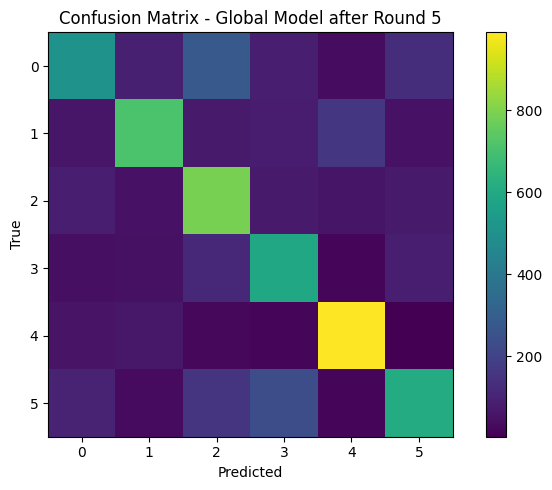


FEDERATED ROUND 6/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=25.3271, clip_scale=1.0000, DQA=2.1930, best_val_acc=0.6518

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=20.7620, clip_scale=1.0000, DQA=2.2770, best_val_acc=0.5966

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=21.5855, clip_scale=1.0000, DQA=2.3255, best_val_acc=0.7280

Client 4 (Hospital-D) streaming train samples: 922
Update norm=18.1960, clip_scale=1.0000, DQA=1.9273, best_val_acc=0.6380
\n======================================================================
Global Model after Round 6
accuracy            : 0.6866
balanced_accuracy   : 0.6861
precision_macro     : 0.6861
recall_macro        : 0.6861
f1_macro            : 0.6832
mcc                 : 0.6248
\nClassification report:
              precision    recall  f1-score   support

           0       0.60      0.55      0.58      1133
           1       0.77      0.69      0.73      1140
           2     

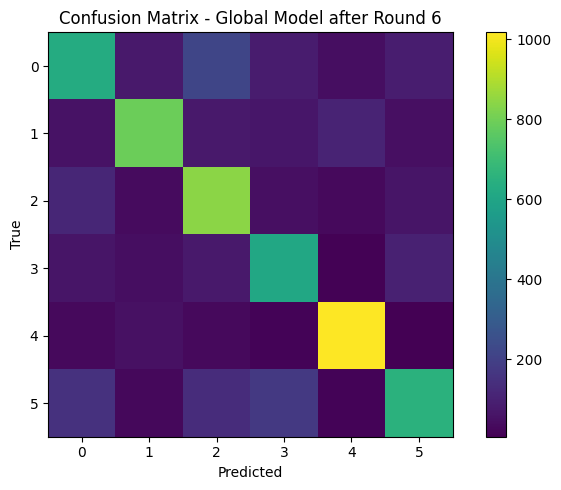


FEDERATED ROUND 7/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=25.3496, clip_scale=1.0000, DQA=2.2798, best_val_acc=0.7415

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=24.4070, clip_scale=1.0000, DQA=2.7172, best_val_acc=0.6650

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=20.7969, clip_scale=1.0000, DQA=2.6324, best_val_acc=0.7691

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=36.5043, clip_scale=1.0000, DQA=2.0879, best_val_acc=0.6195
\n======================================================================
Global Model after Round 7
accuracy            : 0.7161
balanced_accuracy   : 0.7145
precision_macro     : 0.7153
recall_macro        : 0.7145
f1_macro            : 0.7127
mcc                 : 0.6599
\nClassification report:
              precision    recall  f1-score   support

           0       0.67      0.59      0.63      1133
           1       0.77      0.71      0.74      1140
           2    

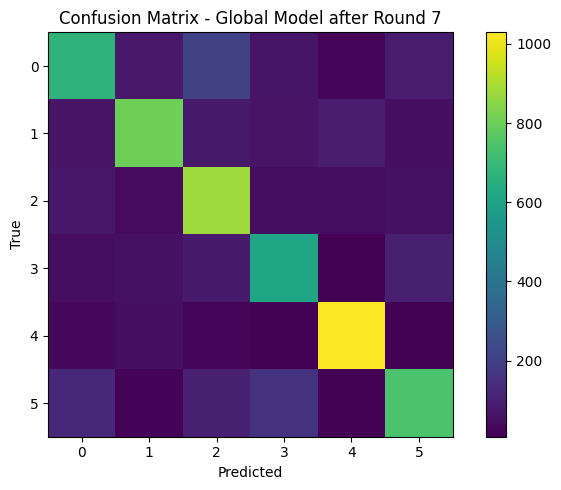


FEDERATED ROUND 8/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=30.2278, clip_scale=1.0000, DQA=2.5761, best_val_acc=0.6941

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=20.2912, clip_scale=1.0000, DQA=2.7124, best_val_acc=0.7174

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=20.7553, clip_scale=1.0000, DQA=2.8910, best_val_acc=0.7554

Client 4 (Hospital-D) streaming train samples: 922
Update norm=9.8247, clip_scale=1.0000, DQA=2.1162, best_val_acc=0.6933
\n======================================================================
Global Model after Round 8
accuracy            : 0.7521
balanced_accuracy   : 0.7514
precision_macro     : 0.7510
recall_macro        : 0.7514
f1_macro            : 0.7486
mcc                 : 0.7033
\nClassification report:
              precision    recall  f1-score   support

           0       0.74      0.62      0.68      1133
           1       0.77      0.78      0.77      1140
           2      

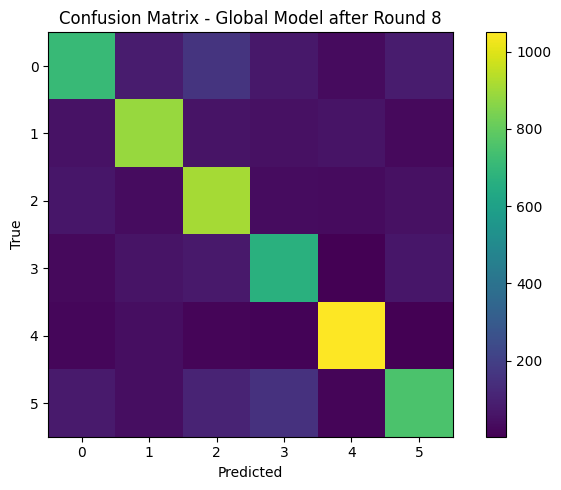


FEDERATED ROUND 9/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=25.1195, clip_scale=1.0000, DQA=2.7301, best_val_acc=0.7610

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=21.0208, clip_scale=1.0000, DQA=2.7261, best_val_acc=0.7642

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=20.9626, clip_scale=1.0000, DQA=3.1397, best_val_acc=0.8000

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=37.9816, clip_scale=1.0000, DQA=2.2881, best_val_acc=0.7089
\n======================================================================
Global Model after Round 9
accuracy            : 0.7741
balanced_accuracy   : 0.7735
precision_macro     : 0.7730
recall_macro        : 0.7735
f1_macro            : 0.7710
mcc                 : 0.7297
\nClassification report:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      1133
           1       0.79      0.81      0.80      1140
           2    

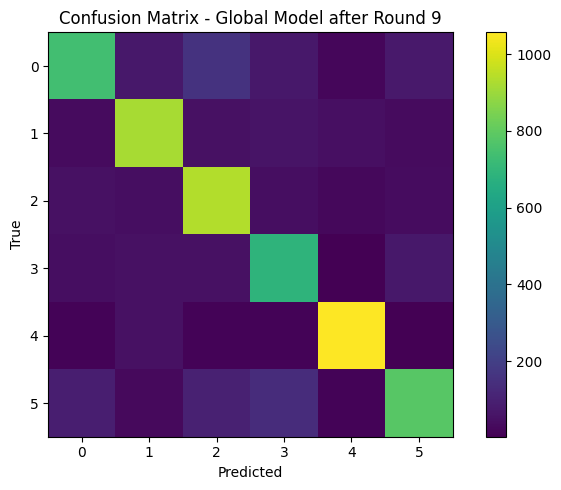


FEDERATED ROUND 10/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=22.3512, clip_scale=1.0000, DQA=2.8674, best_val_acc=0.7129

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=19.7914, clip_scale=1.0000, DQA=2.9421, best_val_acc=0.6836

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=16.9254, clip_scale=1.0000, DQA=3.3190, best_val_acc=0.8239

Client 4 (Hospital-D) streaming train samples: 922
Update norm=19.2643, clip_scale=1.0000, DQA=2.4511, best_val_acc=0.7055
\n======================================================================
Global Model after Round 10
accuracy            : 0.7775
balanced_accuracy   : 0.7770
precision_macro     : 0.7777
recall_macro        : 0.7770
f1_macro            : 0.7757
mcc                 : 0.7334
\nClassification report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      1133
           1       0.84      0.77      0.80      1140
           2   

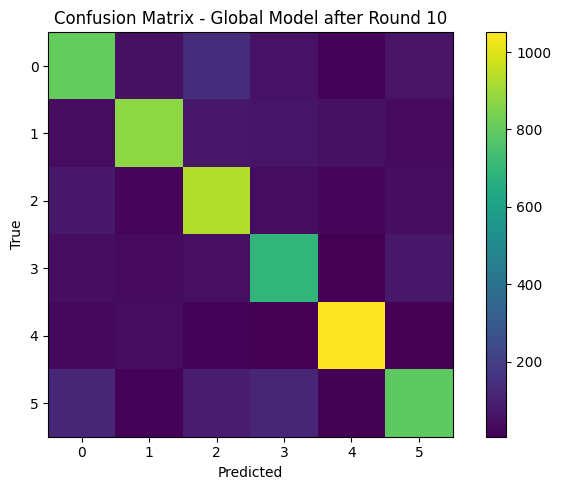


FEDERATED ROUND 11/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=24.5427, clip_scale=1.0000, DQA=3.0490, best_val_acc=0.7870

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=15.9260, clip_scale=1.0000, DQA=3.2486, best_val_acc=0.7837

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=8.8043, clip_scale=1.0000, DQA=3.5045, best_val_acc=0.7967

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=33.7197, clip_scale=1.0000, DQA=2.4395, best_val_acc=0.7447
\n======================================================================
Global Model after Round 11
accuracy            : 0.8044
balanced_accuracy   : 0.8039
precision_macro     : 0.8035
recall_macro        : 0.8039
f1_macro            : 0.8029
mcc                 : 0.7654
\nClassification report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1133
           1       0.85      0.80      0.82      1140
           2   

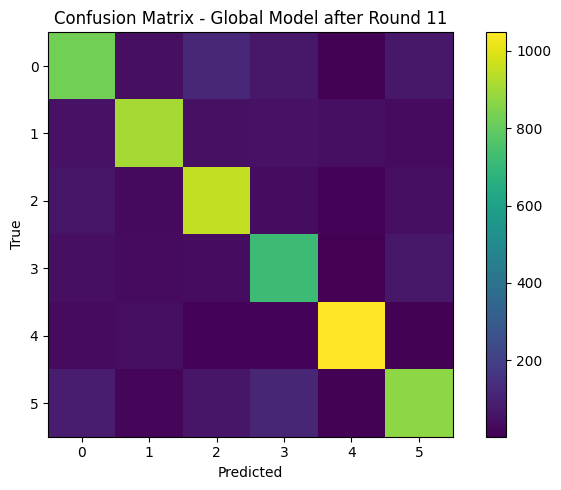


FEDERATED ROUND 12/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=21.7053, clip_scale=1.0000, DQA=3.2288, best_val_acc=0.7788

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=18.8461, clip_scale=1.0000, DQA=3.2091, best_val_acc=0.7899

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=23.8747, clip_scale=1.0000, DQA=3.6681, best_val_acc=0.8297

Client 4 (Hospital-D) streaming train samples: 922
Update norm=13.8612, clip_scale=1.0000, DQA=2.4889, best_val_acc=0.7178
\n======================================================================
Global Model after Round 12
accuracy            : 0.8107
balanced_accuracy   : 0.8091
precision_macro     : 0.8109
recall_macro        : 0.8091
f1_macro            : 0.8084
mcc                 : 0.7733
\nClassification report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      1133
           1       0.87      0.78      0.82      1140
           2   

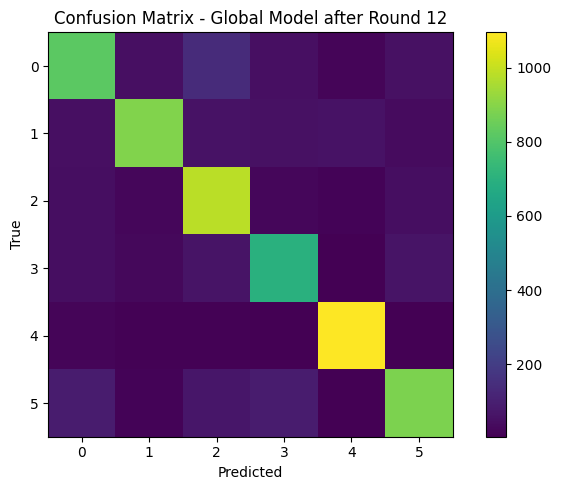


FEDERATED ROUND 13/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=25.8057, clip_scale=1.0000, DQA=3.2805, best_val_acc=0.8211

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=20.5916, clip_scale=1.0000, DQA=3.4344, best_val_acc=0.8455

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=18.6228, clip_scale=1.0000, DQA=3.8199, best_val_acc=0.8341

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=31.6770, clip_scale=1.0000, DQA=2.6547, best_val_acc=0.7902
\n======================================================================
Global Model after Round 13
accuracy            : 0.8346
balanced_accuracy   : 0.8338
precision_macro     : 0.8338
recall_macro        : 0.8338
f1_macro            : 0.8322
mcc                 : 0.8020
\nClassification report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      1133
           1       0.86      0.84      0.85      1140
           2  

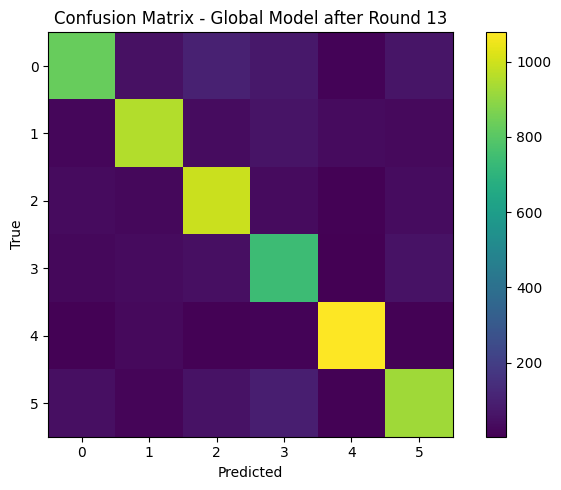


FEDERATED ROUND 14/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=23.3204, clip_scale=1.0000, DQA=3.3706, best_val_acc=0.8329

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=20.7842, clip_scale=1.0000, DQA=3.7191, best_val_acc=0.7995

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=22.5199, clip_scale=1.0000, DQA=4.0194, best_val_acc=0.8650

Client 4 (Hospital-D) streaming train samples: 922
Update norm=15.6121, clip_scale=1.0000, DQA=2.6091, best_val_acc=0.8037
\n======================================================================
Global Model after Round 14
accuracy            : 0.8396
balanced_accuracy   : 0.8378
precision_macro     : 0.8402
recall_macro        : 0.8378
f1_macro            : 0.8371
mcc                 : 0.8081
\nClassification report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.81      1133
           1       0.86      0.84      0.85      1140
           2   

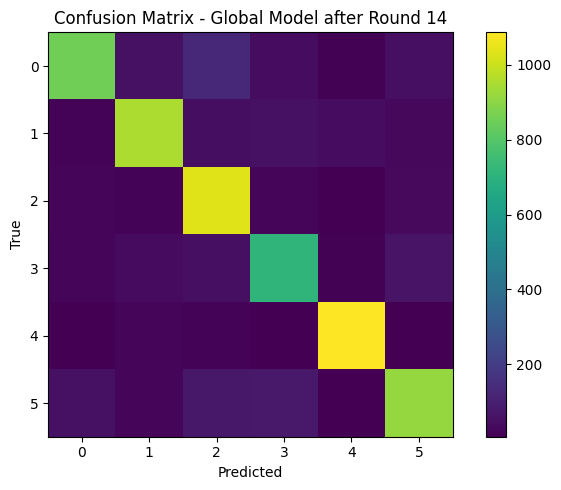


FEDERATED ROUND 15/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=27.4856, clip_scale=1.0000, DQA=3.5805, best_val_acc=0.8618

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=24.3300, clip_scale=1.0000, DQA=3.7988, best_val_acc=0.8553

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=8.4044, clip_scale=1.0000, DQA=4.0568, best_val_acc=0.8423

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=33.3500, clip_scale=1.0000, DQA=3.0606, best_val_acc=0.7724
\n======================================================================
Global Model after Round 15
accuracy            : 0.8525
balanced_accuracy   : 0.8517
precision_macro     : 0.8518
recall_macro        : 0.8517
f1_macro            : 0.8503
mcc                 : 0.8234
\nClassification report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1133
           1       0.88      0.85      0.87      1140
           2   

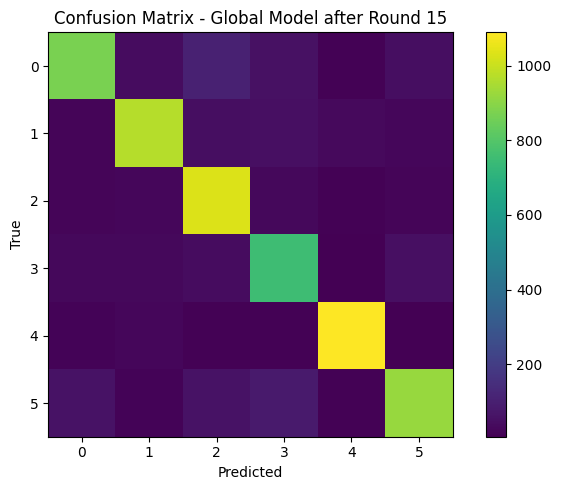


FEDERATED ROUND 16/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=21.4438, clip_scale=1.0000, DQA=3.4243, best_val_acc=0.8235

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=12.6163, clip_scale=1.0000, DQA=3.7694, best_val_acc=0.8237

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=17.8913, clip_scale=1.0000, DQA=4.5147, best_val_acc=0.8767

Client 4 (Hospital-D) streaming train samples: 922
Update norm=9.1572, clip_scale=1.0000, DQA=2.9031, best_val_acc=0.7914
\n======================================================================
Global Model after Round 16
accuracy            : 0.8599
balanced_accuracy   : 0.8583
precision_macro     : 0.8580
recall_macro        : 0.8583
f1_macro            : 0.8575
mcc                 : 0.8319
\nClassification report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1133
           1       0.85      0.88      0.87      1140
           2    

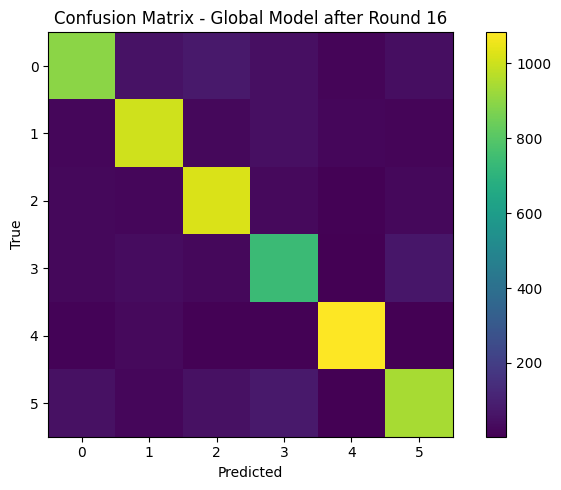


FEDERATED ROUND 17/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=28.2012, clip_scale=1.0000, DQA=3.8433, best_val_acc=0.8667

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=20.8698, clip_scale=1.0000, DQA=4.0940, best_val_acc=0.8602

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=18.5681, clip_scale=1.0000, DQA=4.4619, best_val_acc=0.8780

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=34.7550, clip_scale=1.0000, DQA=3.1135, best_val_acc=0.8407
\n======================================================================
Global Model after Round 17
accuracy            : 0.8655
balanced_accuracy   : 0.8639
precision_macro     : 0.8650
recall_macro        : 0.8639
f1_macro            : 0.8634
mcc                 : 0.8388
\nClassification report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1133
           1       0.88      0.88      0.88      1140
           2  

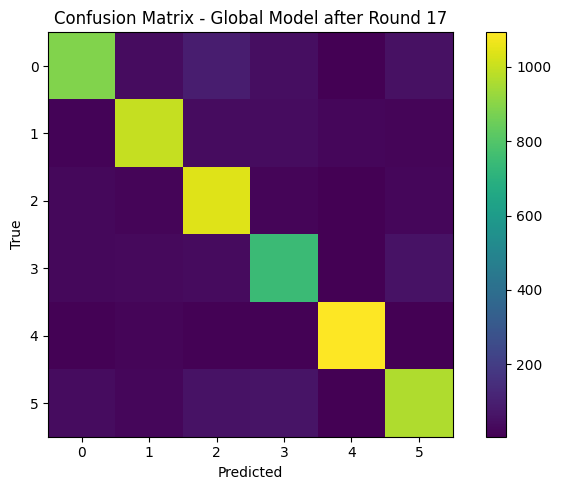


FEDERATED ROUND 18/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=24.6738, clip_scale=1.0000, DQA=3.5720, best_val_acc=0.8612

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=13.2793, clip_scale=1.0000, DQA=4.2872, best_val_acc=0.8671

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=12.7918, clip_scale=1.0000, DQA=4.6581, best_val_acc=0.8748

Client 4 (Hospital-D) streaming train samples: 922
Update norm=10.2866, clip_scale=1.0000, DQA=3.1777, best_val_acc=0.7669
\n======================================================================
Global Model after Round 18
accuracy            : 0.8724
balanced_accuracy   : 0.8702
precision_macro     : 0.8713
recall_macro        : 0.8702
f1_macro            : 0.8700
mcc                 : 0.8470
\nClassification report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1133
           1       0.87      0.89      0.88      1140
           2   

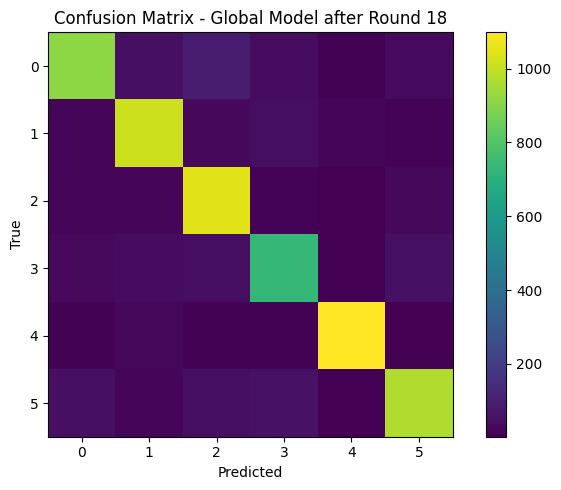


FEDERATED ROUND 19/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=24.3763, clip_scale=1.0000, DQA=4.0876, best_val_acc=0.8715

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=24.1781, clip_scale=1.0000, DQA=4.1522, best_val_acc=0.8862

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=17.3420, clip_scale=1.0000, DQA=4.7749, best_val_acc=0.9057

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=34.5669, clip_scale=1.0000, DQA=3.1634, best_val_acc=0.8309
\n======================================================================
Global Model after Round 19
accuracy            : 0.8732
balanced_accuracy   : 0.8714
precision_macro     : 0.8726
recall_macro        : 0.8714
f1_macro            : 0.8713
mcc                 : 0.8479
\nClassification report:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1133
           1       0.87      0.89      0.88      1140
           2  

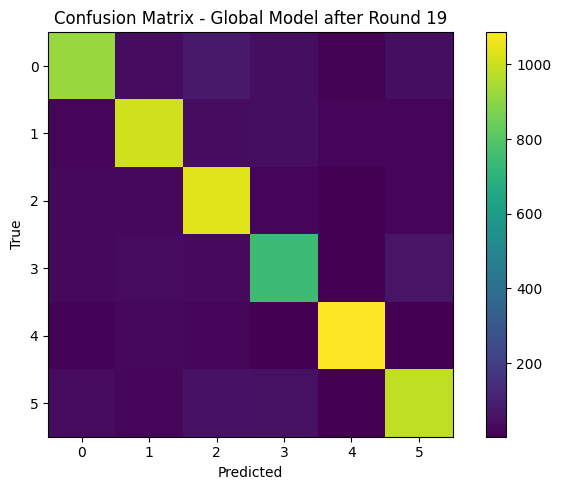


FEDERATED ROUND 20/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=23.9904, clip_scale=1.0000, DQA=4.5524, best_val_acc=0.8659

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=21.2628, clip_scale=1.0000, DQA=4.0267, best_val_acc=0.8671

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=19.2453, clip_scale=1.0000, DQA=4.5493, best_val_acc=0.9080

Client 4 (Hospital-D) streaming train samples: 922
Update norm=16.5677, clip_scale=1.0000, DQA=3.4870, best_val_acc=0.8773
\n======================================================================
Global Model after Round 20
accuracy            : 0.8847
balanced_accuracy   : 0.8839
precision_macro     : 0.8838
recall_macro        : 0.8839
f1_macro            : 0.8829
mcc                 : 0.8619
\nClassification report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1133
           1       0.89      0.89      0.89      1140
           2   

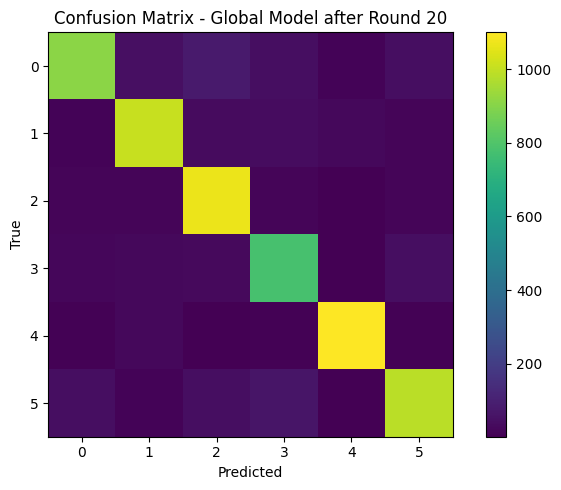


FEDERATED ROUND 21/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=27.2132, clip_scale=1.0000, DQA=4.1939, best_val_acc=0.8943

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=20.1573, clip_scale=1.0000, DQA=4.3697, best_val_acc=0.8846

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=17.3832, clip_scale=1.0000, DQA=4.7953, best_val_acc=0.9041

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=33.7689, clip_scale=1.0000, DQA=3.3138, best_val_acc=0.8488
\n======================================================================
Global Model after Round 21
accuracy            : 0.8927
balanced_accuracy   : 0.8915
precision_macro     : 0.8910
recall_macro        : 0.8915
f1_macro            : 0.8907
mcc                 : 0.8713
\nClassification report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1133
           1       0.90      0.90      0.90      1140
           2  

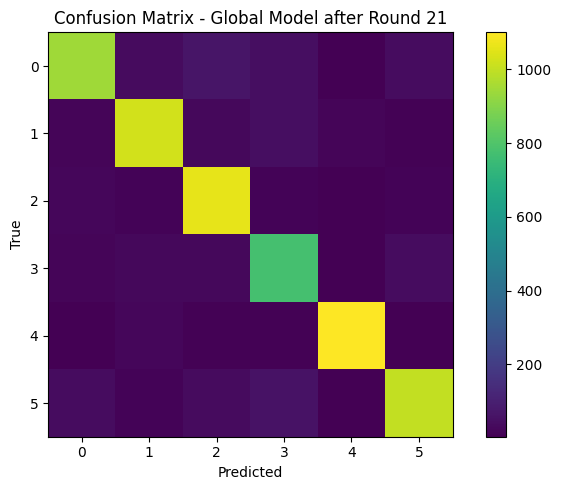


FEDERATED ROUND 22/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=26.7073, clip_scale=1.0000, DQA=4.5359, best_val_acc=0.8824

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=12.5044, clip_scale=1.0000, DQA=4.5582, best_val_acc=0.9106

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=7.6226, clip_scale=1.0000, DQA=4.8622, best_val_acc=0.9061

Client 4 (Hospital-D) streaming train samples: 922
Update norm=6.6709, clip_scale=1.0000, DQA=3.2428, best_val_acc=0.8466
\n======================================================================
Global Model after Round 22
accuracy            : 0.8922
balanced_accuracy   : 0.8909
precision_macro     : 0.8903
recall_macro        : 0.8909
f1_macro            : 0.8902
mcc                 : 0.8707
\nClassification report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1133
           1       0.91      0.89      0.90      1140
           2     

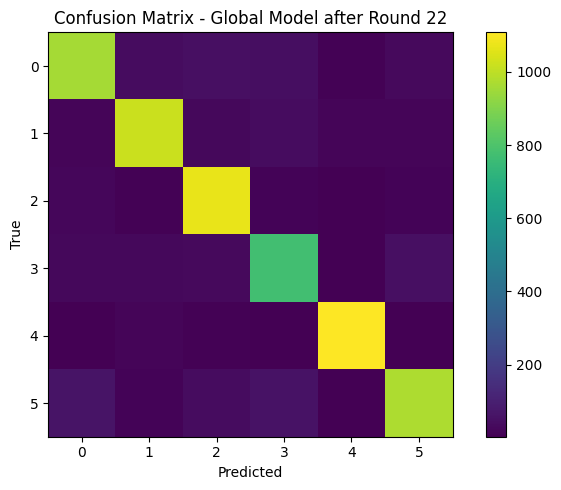


FEDERATED ROUND 23/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=24.6961, clip_scale=1.0000, DQA=4.2396, best_val_acc=0.9220

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=23.3079, clip_scale=1.0000, DQA=4.5339, best_val_acc=0.8829

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=17.8351, clip_scale=1.0000, DQA=5.4120, best_val_acc=0.8927

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=31.8829, clip_scale=1.0000, DQA=3.4658, best_val_acc=0.8650
\n======================================================================
Global Model after Round 23
accuracy            : 0.8975
balanced_accuracy   : 0.8958
precision_macro     : 0.8959
recall_macro        : 0.8958
f1_macro            : 0.8954
mcc                 : 0.8770
\nClassification report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1133
           1       0.91      0.90      0.90      1140
           2  

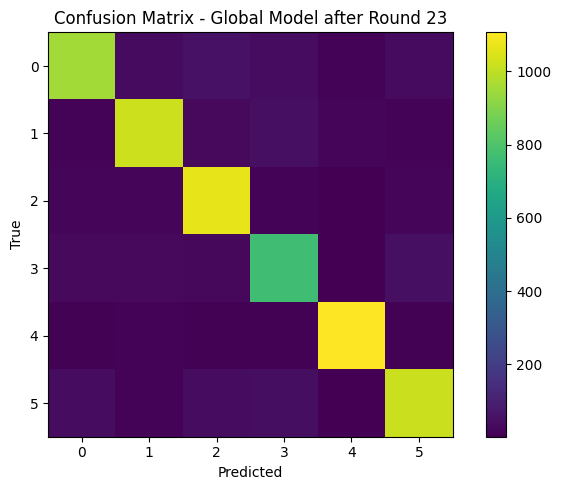


FEDERATED ROUND 24/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=9.6863, clip_scale=1.0000, DQA=4.4496, best_val_acc=0.9082

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=14.7684, clip_scale=1.0000, DQA=4.6867, best_val_acc=0.8961

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=19.8675, clip_scale=1.0000, DQA=5.7998, best_val_acc=0.9217

Client 4 (Hospital-D) streaming train samples: 922
Update norm=14.1629, clip_scale=1.0000, DQA=3.9672, best_val_acc=0.8712
\n======================================================================
Global Model after Round 24
accuracy            : 0.9028
balanced_accuracy   : 0.9013
precision_macro     : 0.9006
recall_macro        : 0.9013
f1_macro            : 0.9008
mcc                 : 0.8833
\nClassification report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1133
           1       0.91      0.91      0.91      1140
           2    

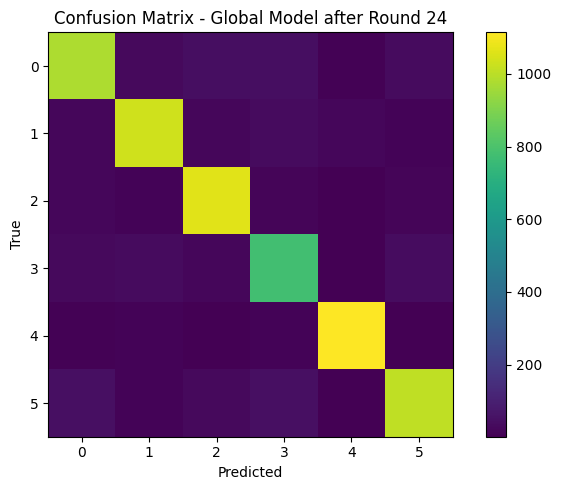


FEDERATED ROUND 25/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=25.2836, clip_scale=1.0000, DQA=4.5697, best_val_acc=0.9089

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=20.7372, clip_scale=1.0000, DQA=4.8266, best_val_acc=0.9171

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=19.5255, clip_scale=1.0000, DQA=5.4910, best_val_acc=0.9252

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=30.5245, clip_scale=1.0000, DQA=3.6063, best_val_acc=0.8569
\n======================================================================
Global Model after Round 25
accuracy            : 0.9039
balanced_accuracy   : 0.9016
precision_macro     : 0.9029
recall_macro        : 0.9016
f1_macro            : 0.9019
mcc                 : 0.8846
\nClassification report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1133
           1       0.91      0.90      0.90      1140
           2  

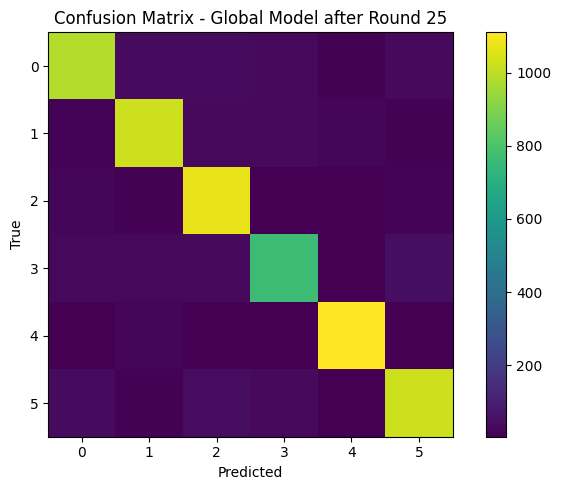

,round,client,samples,epochs,lr,raw_update_norm,clip_scale,dqa,best_val_accuracy,final_loss,final_val_loss,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mcc,epsilon_estimate,round_time_seconds
95,24,Hospital-D,922,5,0.0012,14.162911,1.0,3.967157,0.871166,0.265362,0.620997,0.902797,0.901309,0.900563,0.901309,0.900759,0.883296,235078.800048,76.795514
96,25,Hospital-A,3481,6,0.0010,25.283587,1.0,4.569692,0.908943,0.280229,0.519222,0.903855,0.901636,0.902907,0.901636,0.901939,0.884589,239926.295609,104.999626
97,25,Hospital-B,3481,5,0.0008,20.737175,1.0,4.826598,0.917073,0.311630,0.414072,0.903855,0.901636,0.902907,0.901636,0.901939,0.884589,239926.295609,104.999626
98,25,Hospital-C,3481,6,0.0006,19.525454,1.0,5.490955,0.925203,0.269016,0.417681,0.903855,0.901636,0.902907,0.901636,0.901939,0.884589,239926.295609,104.999626
99,25,Hospital-D,3481,5,0.0012,30.524467,1.0,3.606260,0.856911,0.376604,0.661008,0.903855,0.901636,0.902907,0.901636,0.901939,0.884589,239926.295609,104.999626


Saved high-accuracy FL logs and global model to /kaggle/working


In [11]:
round_logs = []
global_weights = global_model.get_weights()

# Persistent streaming pointers: each client moves through its ECG stream across rounds.
client_stream_positions = [0 for _ in range(NUM_CLIENTS)]

for rnd in range(1, FED_ROUNDS + 1):
    print("\n" + "="*80)
    print(f"FEDERATED ROUND {rnd}/{FED_ROUNDS}")
    print("="*80)

    participating_updates = []
    participating_counts = []
    client_logs = []

    round_start = time.time()

    for cid, (cx, cy) in enumerate(client_datasets):
        cfg = CLIENT_CONFIGS[cid]

        # Real-time component: receive the next ECG streaming window.
        start = client_stream_positions[cid]
        end = start + STREAM_CHUNK_SIZE

        if start >= len(cx):
            # When the local stream ends, reshuffle and continue.
            idx = np.arange(len(cx))
            np.random.shuffle(idx)
            cx, cy = cx[idx], cy[idx]
            client_datasets[cid] = (cx, cy)
            start = 0
            end = STREAM_CHUNK_SIZE

        X_stream = cx[start:min(end, len(cx))]
        y_stream = cy[start:min(end, len(cy))]
        client_stream_positions[cid] = end

        if len(X_stream) < 40:
            print(f"Skipping client {cid+1}; not enough streaming samples.")
            continue

        # Safe stratified split.
        stratify_labels = np.argmax(y_stream, axis=1)
        unique_classes, class_counts = np.unique(stratify_labels, return_counts=True)
        can_stratify = (
            len(unique_classes) > 1
            and len(X_stream) >= 40
            and np.min(class_counts) >= 2
        )

        if can_stratify:
            X_local, X_val, y_local, y_val = train_test_split(
                X_stream,
                y_stream,
                test_size=0.15,
                random_state=SEED + rnd + cid,
                stratify=stratify_labels
            )
        else:
            X_local, X_val, y_local, y_val = train_test_split(
                X_stream,
                y_stream,
                test_size=0.15,
                random_state=SEED + rnd + cid,
                shuffle=True
            )

        print(f"\nClient {cid+1} ({cfg['name']}) streaming train samples: {len(X_local)}")
        time.sleep(cfg["latency"])

        local_model = clone_compiled_model(global_model, lr=cfg["lr"])
        old_weights = local_model.get_weights()

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                patience=4,
                restore_best_weights=True,
                mode="max",
                min_delta=1e-4
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2,
                min_lr=1e-5
            )
        ]

        class_weight = compute_balanced_class_weight(y_local)

        history = local_model.fit(
            X_local, y_local,
            validation_data=(X_val, y_val),
            epochs=cfg["epochs"],
            batch_size=LOCAL_BATCH_SIZE,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=0
        )

        new_weights = local_model.get_weights()
        raw_update = get_update(new_weights, old_weights)

        clipped_update, raw_norm, clip_scale = clip_weights_update(raw_update, clip_norm=CLIP_NORM)
        private_update = add_gaussian_noise(
            clipped_update,
            noise_multiplier=NOISE_MULTIPLIER,
            clip_norm=CLIP_NORM
        )

        dqa = client_data_quality_score(history, y_local)

        participating_updates.append(private_update)
        participating_counts.append(len(X_local))

        best_val_acc = float(np.max(history.history.get("val_accuracy", [0])))
        client_logs.append({
            "round": rnd,
            "client": cfg["name"],
            "samples": len(X_local),
            "epochs": cfg["epochs"],
            "lr": cfg["lr"],
            "raw_update_norm": raw_norm,
            "clip_scale": clip_scale,
            "dqa": dqa,
            "best_val_accuracy": best_val_acc,
            "final_loss": history.history["loss"][-1],
            "final_val_loss": history.history.get("val_loss", [np.nan])[-1],
        })

        print(
            f"Update norm={raw_norm:.4f}, clip_scale={clip_scale:.4f}, "
            f"DQA={dqa:.4f}, best_val_acc={best_val_acc:.4f}"
        )

    # Secure aggregation simulation
    if participating_updates:
        agg_update = secure_aggregate_simulated(participating_updates, participating_counts)
        global_weights = apply_update(global_weights, agg_update)
        global_model.set_weights(global_weights)

    round_time = time.time() - round_start
    metrics = evaluate_model(
        global_model,
        X_global_test,
        y_global_test,
        title=f"Global Model after Round {rnd}",
        plot_roc=False
    )
    eps = estimate_epsilon(rnd, NOISE_MULTIPLIER, delta=DELTA)

    for log in client_logs:
        log.update(metrics)
        log["epsilon_estimate"] = eps
        log["round_time_seconds"] = round_time
        round_logs.append(log)

results_df = pd.DataFrame(round_logs)
display(results_df.tail())
results_df.to_csv("/kaggle/working/pp_hfl_realtime_round_logs_high_accuracy.csv", index=False)
global_model.save("/kaggle/working/pp_hfl_realtime_global_model_high_accuracy.keras")
print("Saved high-accuracy FL logs and global model to /kaggle/working")

## Final Evaluation and Plots

\n======================================================================
Final Global PP-HFL Model before Personalization
accuracy            : 0.9039
balanced_accuracy   : 0.9016
precision_macro     : 0.9029
recall_macro        : 0.9016
f1_macro            : 0.9019
mcc                 : 0.8846
\nClassification report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1133
           1       0.91      0.90      0.90      1140
           2       0.87      0.94      0.91      1135
           3       0.87      0.84      0.86       903
           4       0.96      0.96      0.96      1153
           5       0.90      0.89      0.90      1151

    accuracy                           0.90      6615
   macro avg       0.90      0.90      0.90      6615
weighted avg       0.90      0.90      0.90      6615



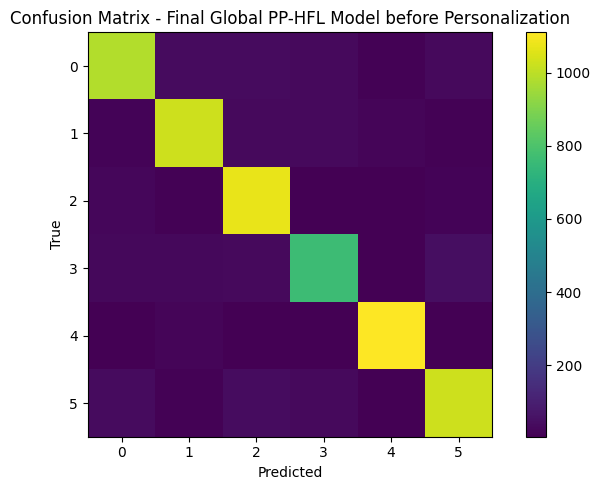

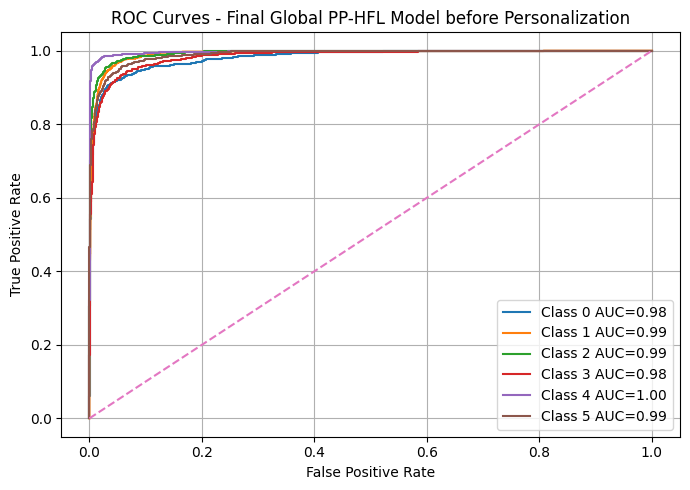


PERSONALIZATION / FINE-TUNING STAGE
Epoch 1/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.9112 - auc: 0.9910 - loss: 0.4270 - precision: 0.9291 - recall: 0.8966 - val_accuracy: 0.9504 - val_auc: 0.9977 - val_loss: 0.3023 - val_precision: 0.9625 - val_recall: 0.9383 - learning_rate: 2.0000e-04
Epoch 2/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9229 - auc: 0.9936 - loss: 0.3849 - precision: 0.9388 - recall: 0.9100 - val_accuracy: 0.9456 - val_auc: 0.9971 - val_loss: 0.3100 - val_precision: 0.9582 - val_recall: 0.9350 - learning_rate: 2.0000e-04
Epoch 3/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9298 - auc: 0.9952 - loss: 0.3559 - precision: 0.9449 - recall: 0.9193 - val_accuracy: 0.9491 - val_auc: 0.9973 - val_loss: 0.2999 - val_precision: 0.9613 - val_recall: 0.9390 - learning_rate: 2.0000e-04
Epoch 4/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.9344 - auc: 0.9954 - loss: 0.3451 - precision: 0.9477 - recall: 0.9237 - val_accura

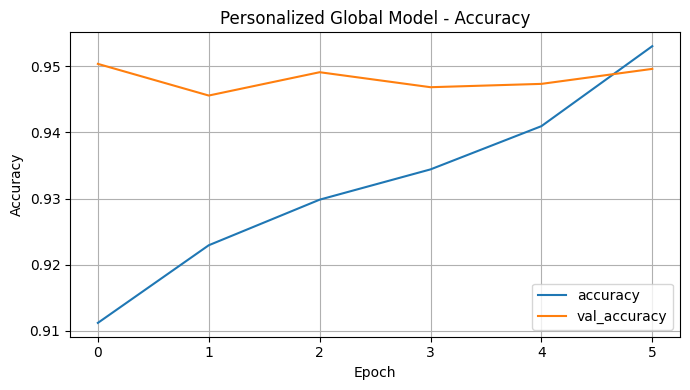

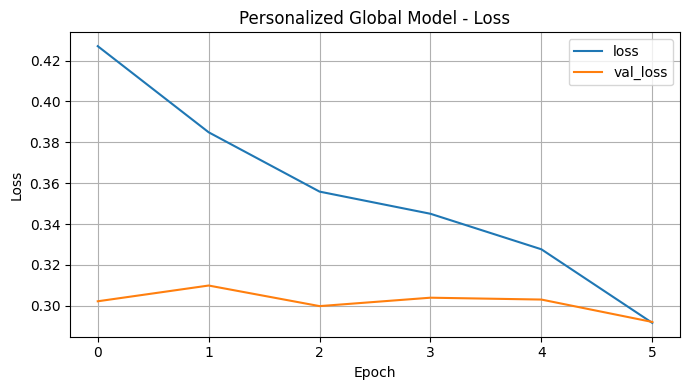

\n======================================================================
Personalized PP-HFL Model Final Test
accuracy            : 0.9152
balanced_accuracy   : 0.9139
precision_macro     : 0.9135
recall_macro        : 0.9139
f1_macro            : 0.9136
mcc                 : 0.8982
\nClassification report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1133
           1       0.91      0.92      0.91      1140
           2       0.92      0.94      0.93      1135
           3       0.86      0.88      0.87       903
           4       0.97      0.97      0.97      1153
           5       0.93      0.89      0.91      1151

    accuracy                           0.92      6615
   macro avg       0.91      0.91      0.91      6615
weighted avg       0.92      0.92      0.92      6615



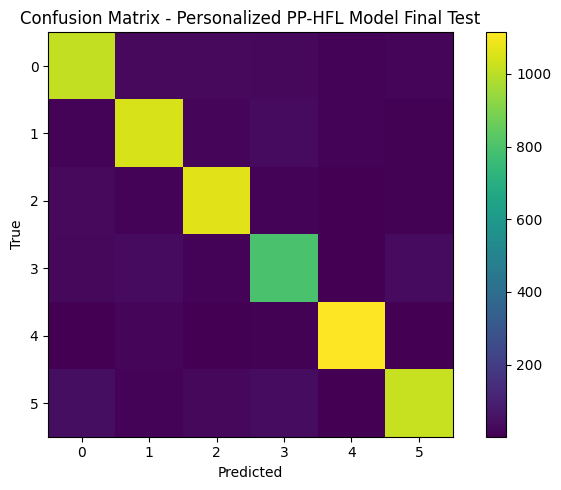

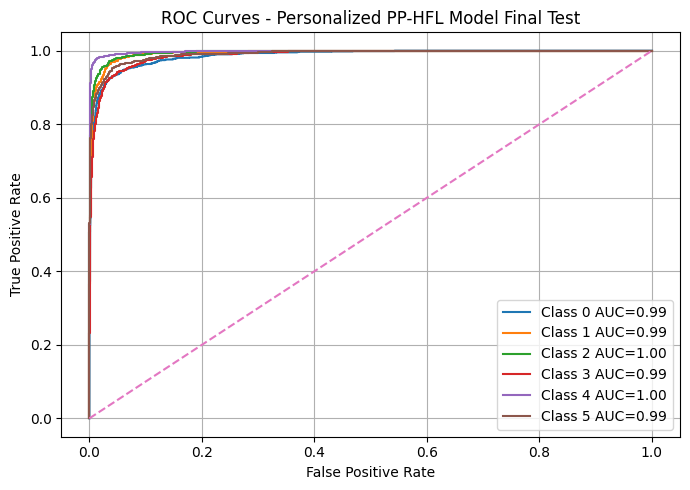

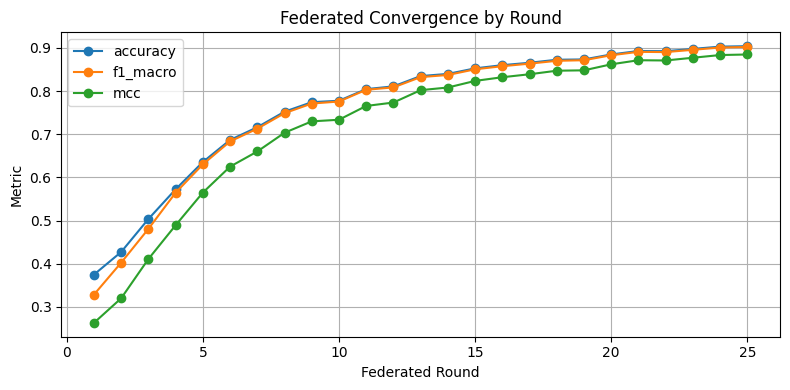

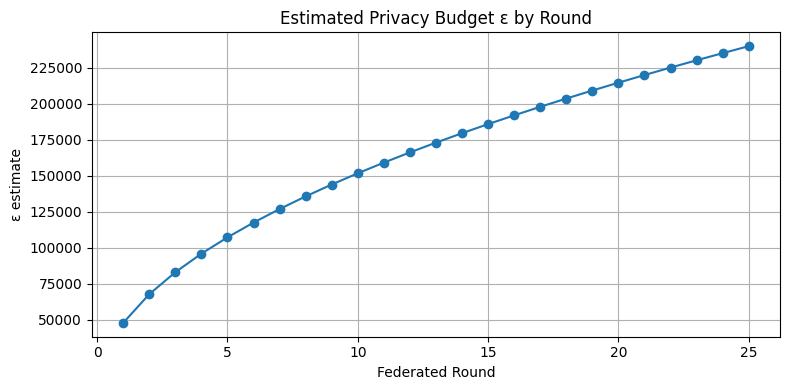

<Figure size 800x400 with 0 Axes>

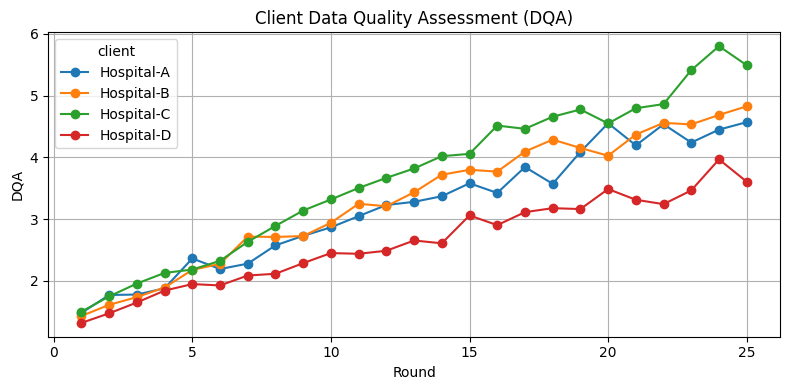

All result files saved to /kaggle/working


In [12]:
# ============================================================
# Final evaluation before personalization
# ============================================================

final_results = evaluate_model(
    global_model,
    X_global_test,
    y_global_test,
    title="Final Global PP-HFL Model before Personalization",
    plot_roc=True
)
pd.DataFrame([final_results]).to_csv("/kaggle/working/pp_hfl_final_global_results_high_accuracy.csv", index=False)

# ============================================================
# Optional personalization / fine-tuning
# ============================================================
# This keeps the federated global model, then performs a short local adaptation.
# In real FL healthcare systems this is common because each hospital can personalize
# the global model to its local ECG distribution.
# For your dissertation, report both:
# 1. Global FL accuracy
# 2. Personalized FL accuracy

if ENABLE_FINAL_PERSONALIZATION:
    print("\n" + "="*80)
    print("PERSONALIZATION / FINE-TUNING STAGE")
    print("="*80)

    personalized_model = clone_compiled_model(global_model, lr=2e-4)

    # Use all federated training data for final local adaptation simulation.
    # This is not central training from scratch; it starts from the federated global model.
    X_personal = np.concatenate([c[0] for c in client_datasets], axis=0)
    y_personal = np.concatenate([c[1] for c in client_datasets], axis=0)

    X_p_train, X_p_val, y_p_train, y_p_val = train_test_split(
        X_personal,
        y_personal,
        test_size=0.15,
        random_state=SEED,
        stratify=np.argmax(y_personal, axis=1)
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            mode="max"
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    class_weight = compute_balanced_class_weight(y_p_train)

    personalization_history = personalized_model.fit(
        X_p_train,
        y_p_train,
        validation_data=(X_p_val, y_p_val),
        epochs=PERSONALIZATION_EPOCHS,
        batch_size=32,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1
    )

    plot_history(personalization_history, title="Personalized Global Model")

    personalized_results = evaluate_model(
        personalized_model,
        X_global_test,
        y_global_test,
        title="Personalized PP-HFL Model Final Test",
        plot_roc=True
    )

    pd.DataFrame([personalized_results]).to_csv(
        "/kaggle/working/pp_hfl_personalized_results_high_accuracy.csv",
        index=False
    )
    personalized_model.save("/kaggle/working/pp_hfl_personalized_model_high_accuracy.keras")

# ============================================================
# Training curves and report plots
# ============================================================

plt.figure(figsize=(8,4))
round_summary = results_df.groupby("round")[["accuracy", "f1_macro", "mcc"]].mean()
for col in round_summary.columns:
    plt.plot(round_summary.index, round_summary[col], marker="o", label=col)
plt.title("Federated Convergence by Round")
plt.xlabel("Federated Round")
plt.ylabel("Metric")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
eps_by_round = results_df.groupby("round")["epsilon_estimate"].mean()
plt.plot(eps_by_round.index, eps_by_round.values, marker="o")
plt.title("Estimated Privacy Budget ε by Round")
plt.xlabel("Federated Round")
plt.ylabel("ε estimate")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
dqa = results_df.groupby(["round", "client"])["dqa"].mean().unstack()
dqa.plot(marker="o", figsize=(8,4))
plt.title("Client Data Quality Assessment (DQA)")
plt.xlabel("Round")
plt.ylabel("DQA")
plt.grid(True)
plt.tight_layout()
plt.show()

print("All result files saved to /kaggle/working")